In [1]:
from lib_analysis import *
from matplotlib.patches import Rectangle

%matplotlib inline

Ratios: [0.00456644 0.00720286 0.01284938 0.02512182 0.05039973 0.10073139
 0.19025139 0.32390004 0.49054742 0.66105079 0.79580531 0.88382707
 0.9333288  0.95904352 0.97175992 0.98062836 0.98590304 0.98893842
 0.99130726]
Fraction 0.2141781168220543 above 3.0 -- 2379418 of 11109529 -- 0.0003000213607811983 error
Fraction 0.25901178888314397 above 3.386513675054067 -- 2370479 of 9152012 -- 0.0003305534616335365 error
Fraction 0.31291418225850015 above 3.8228249571094017 -- 2358856 of 7538348 -- 0.0003642184223403804 error
Fraction 0.3769924297609801 above 4.315349664862988 -- 2341811 of 6211825 -- 0.00040122722478707793 error
Fraction 0.45236450992139315 above 4.871330217566165 -- 2314281 of 5115965 -- 0.000442115985274137 error
Fraction 0.5384038732066818 above 5.498942132497308 -- 2268821 of 4213976 -- 0.00048714020111458516 error
Fraction 0.6320036318008408 above 6.2074142433443695 -- 2194036 of 3471556 -- 0.0005367078066701804 error
Fraction 0.726344263062995 above 7.007164407270366

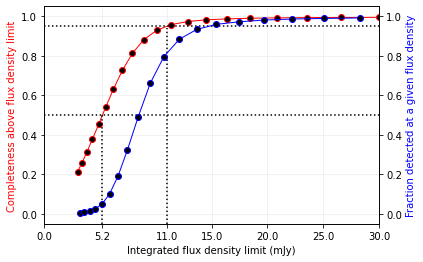

In [2]:
datafiles = glob.glob('../completeness/*.txt')

#for datafile in datafiles:
#    with open(datafile,'r') as f:
#        lines = f.readlines()
#    with open(datafile,'w') as f:
#        for i, line in enumerate(lines):
#            if i == 0 or not line.startswith('c'):
#                f.write(line)

if not os.path.exists('../completeness/concat.fits'):
    # cycle idx ra dec fv rfv efv
    t = Table.read(datafiles[0], format='ascii')
    pointing_name = os.path.basename(datafiles[0]).split('-')[0]
    print('Concatenating %s' % pointing_name)
    t = keep_sources_pointing(t, pointing_name)
    
    for datafile in datafiles[1:]:
        pointing_name = os.path.basename(datafile).split('-')[0]
        print('Concatenating %s' % pointing_name)
        tadd = Table.read(datafile, format='ascii')
        # isolate sources that belongs to this pointing
        tadd = keep_sources_pointing(tadd, pointing_name)
        # pile up
        t = vstack([t,tadd])

    t['fv'].name = 'f_inj'
    t['rfv'].name = 'f_meas'
    t['efv'].name = 'f_meas_err'    
    
    t['f_inj'] *= 1e3
    t['f_meas'] *= 1e3
    t['f_meas_err'] *= 1e3
    
    t.write('../completeness/concat.fits', format='fits')
else:
    t = Table.read('../completeness/concat.fits', format='fits')

logmin=np.log10(3)
logmax=np.log10(30)
steps=20

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

# all detected sources are reset to the original value
t['f_meas'][np.where(t['f_meas'] != 0.0)] = t['f_inj'][np.where(t['f_meas'] != 0.0)] 

f_inj_vals = np.histogram(t['f_inj'], bins=10**np.linspace(logmin,logmax,steps))[0].astype(float)
f_meas_vals = np.histogram(t['f_meas'], bins=10**np.linspace(logmin,logmax,steps))[0].astype(float)
ratios = np.divide(f_meas_vals, f_inj_vals, out=np.zeros_like(f_meas_vals), where=f_meas_vals!=0)
print('Ratios:', ratios)

p = []; f = []
for lf in np.linspace(logmin,logmax,steps):
    flux=10**lf

    idxf_det=(t['f_inj']>0) & (t['f_meas']>flux) # idx detected
    idxf_inj=(t['f_inj']>flux) # idx injected

    n1=len(t[idxf_det])
    n2=len(t[idxf_inj])

    f.append(flux)
    p.append(n1/n2)
    print('Fraction %s above %s -- %s of %s -- %s error' % (n1/n2, flux, n1, n2, 1/np.sqrt(n2)) )


ax1.plot(f, p, color='r',markerfacecolor='k',linewidth=1,linestyle='-',marker='o')
print("wendy",f[:-1] + np.diff(f) / 2, ratios)
ax2.plot(f[:-1] + np.diff(f) / 2, ratios, color='b',markerfacecolor='k',linewidth=1,linestyle='-',marker='o')
print('Blue dots:', f[:-1] + np.diff(f) / 2, ratios)

#plt.xlim(1000.0*10**min,1000.0*10**max)
#plt.xlim(1000.0*10**min,1.2)
#plt.ylim(0.2,1.05)
ax1.set_xlabel('Integrated flux density limit (mJy)')
ax1.set_ylabel('Completeness above flux density limit',color='r')
ax2.set_ylabel('Fraction detected at a given flux density',color='b')
# 50%
ax1.axvline(5.2, ymax=0.5, color='k',ls=':')
ax1.axhline(0.5,color='k',ls=':')
# 90%
#ax1.axvline(9.5, ymax=0.85, color='k',ls=':')
#ax1.axhline(0.9,color='k',ls=':')
# 95%
ax1.axvline(11, ymax=0.9, color='k',ls=':')
ax1.axhline(0.95,color='k',ls=':')
ax1.set_xticks([0,5.2,11,15,20,25,30])
for i, tick in enumerate(ax1.get_xticklines()):
    if i == 1 or i == 2: tick.set_color('red')
ax1.set_ylim(-0.05,1.05)
ax2.set_ylim(-0.05,1.05)
ax1.set_xlim(0,30)
ax2.set_xlim(0,30)
ax1.grid(alpha=.2)
plt.savefig('completeness.pdf')

FALSE POSITIVES

Total fake sources: 625
False positive: 1.47%


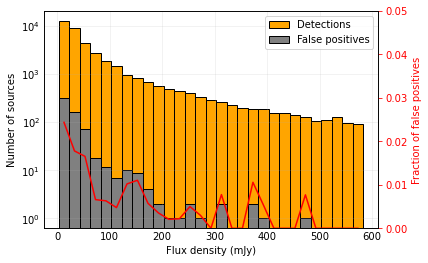

In [3]:
t = Table.read('../LoLSS_DR1_rolling.srl.fits', format='fits')
t_fp = Table.read('../LoLSS_DR1_falsepositive.srl.fits', format='fits')
print("Total fake sources:", len(t_fp))
print("False positive: %.2f%%" % (100*len(t_fp)/len(t)))

fig = plt.figure(figsize=(6, 4))
fig.subplots_adjust(wspace=0)
ax = fig.add_subplot(111)
ax2 = ax.twinx()
ax.tick_params(direction='in', top=True, right=True)
fig.subplots_adjust(hspace=0)

ax.set_xlabel(r'Flux density (mJy)')
ax.set_ylabel(r'Number of sources')
ax2.set_ylabel(r'Fraction of false positives')
ax.set_yticklabels([])

fd_real = t['Total_flux']
fd_false = t_fp['Total_flux']

bins = np.arange(3, 600, 20)
n_real, bins, patches = ax.hist(fd_real, bins=bins, orientation='vertical', ec='black', histtype='bar', alpha=1, color='orange')
n_false, bins, patches = ax.hist(fd_false, bins=bins, orientation='vertical', ec='black', histtype='bar', alpha=1, color='gray')

bin_w = (max(bins) - min(bins)) / (len(bins) - 1)
ax2.plot(np.arange(min(bins)+bin_w/2, max(bins), bin_w), n_false/n_real, color='red')

ax.tick_params(axis=u'both', which=u'both',length=0)
ax.grid(alpha=.2)
ax.set_yscale('log')
ax2.set_ylim(ymin=0,ymax=.05)
ax2.yaxis.label.set_color('red')
ax2.tick_params(axis='y', colors='red')

#create legend
handles = [Rectangle((0,0),1,1,color=c,ec="k") for c in ['orange','gray']]
labels= ["Detections","False positives"]
ax.legend(handles, labels)

fig.savefig('falsepositive_hist.pdf', bbox_inches='tight', facecolor='w')